In [33]:
import mne
import numpy as np
from scipy.signal import convolve
import os
import scipy.io
import numpy as np
import pandas as pd
from scipy.signal import convolve, butter, filtfilt
from scipy.fft import fft
import matplotlib.pyplot as plt


In [34]:
def FIR_LP(z, Fs, Fc, Sc=1):
    """ 
    Parameters:
    z : ndarray
        Input signal.
    Fs : float
        Sampling frequency.
    Fc : float
        Cutoff frequency.
    Sc : float, optional
        Scaling factor, default is 1.
        
    Returns:
    s : ndarray
        Filtered signal (same size as input).
    """
    Lt = (2 * Sc) / Fc   # Length in seconds (total duration)
    dt = 1 / Fs         # Sample interval
    tp = np.arange(-Lt, Lt + dt, dt)  # Time vector

    # Impulse response of ideal low-pass filter (sinc-based)
    IR = 2 * (Fc / Fs) * np.sinc(2 * Fc * tp)

    # Optionally apply Hamming window:
    # h = np.hamming(IR.size)
    # IR *= h

    # Apply convolution ('same' output size as input signal)
    s = convolve(z, IR, mode='same')

    return s

def highpass(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

In [35]:
file = "../data/Exp2.2_3086.edf"
data = mne.io.read_raw_edf(file, include = ['EEG','EMG'])
# raw_data = data.get_data()
# # you can get the metadata included in the file and a list of all channels:
info = data.info
channels = data.ch_names

X = data.get_data(picks=['EEG','EMG'], return_times=True)

Extracting EDF parameters from /media/volume/volume_spatial/hugo/Xenium-workflow/data/Exp2.2_3086.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


In [36]:
data.to_data_frame(picks = 'EEG', index = 'time', time_format = 'datetime')

channel,EEG
time,
2023-05-12 19:00:00+00:00,-15.182727
2023-05-12 19:00:00.002000+00:00,-18.387121
2023-05-12 19:00:00.004000+00:00,-25.406271
2023-05-12 19:00:00.006000+00:00,-34.714275
2023-05-12 19:00:00.008000+00:00,-31.815061
...,...
2023-05-13 18:59:59.990000+00:00,22.659648
2023-05-13 18:59:59.992000+00:00,20.981155
2023-05-13 18:59:59.994000+00:00,12.893874


In [37]:
len(X[0][0]),len(X[1])

(43200000, 43200000)

In [38]:
folder_path = '../data'
file_name = 'Exp2.2_3160.edf'

output_excel = os.path.join(os.path.dirname(folder_path), 'All_SleepSummary.xlsx')
all_data = pd.DataFrame()

EEG = X[0][0]
EMG = X[0][1]

In [39]:
Fe = 500 ### Sampling Frequency

# EEG pre-processing
EEG = FIR_LP(EEG, Fe, 20)
EEG = EEG - convolve(EEG, np.ones(5*Fe)/ (5*Fe), mode='same')
EEG = (EEG - np.mean(EEG)) / np.std(EEG)

# EMG pre-processing
EMG = highpass(EMG, 10, Fe)
EMG = (EMG - np.mean(EMG)) / np.std(EMG)

# Parameters for sliding window spectral analysis
K = 8 * Fe                  # Window Size
Ovlp = int(K * 0.75)        # Overlap consecutive windows = 75 %
ni, ns = 0, K

f = np.arange(0, K//2) * Fe / K
ki = np.where(f > 1)[0][0]
tti, tts = np.where(f > 6)[0][0], np.where(f > 10)[0][0] # Theta band frequency (6-10Hz)
dti, dts = np.where(f > 0.5)[0][0], np.where(f > 4)[0][0] # Delta band frequency (0.5-4Hz)
si, ss = np.where(f > 11)[0][0], np.where(f > 14)[0][0] # Sigma band frequency (11-14Hz)

T = (K - Ovlp) / Fe
print(f'Final bin size = {T}s')

Final bin size = 2.0s


In [40]:
R, Spdl, P_EMG_t, tp = [], [], [], []

while ns < len(EEG):
    S_seg = EEG[ni:ns]                                      # EEG signal in the window
    F_S = fft(S_seg - np.mean(S_seg)) / K                   # Compute FFT (convert signal from time to frequency domain)
    F_S = F_S * np.conj(F_S)                                # Compute power spectrum (power at each frequency)

    R.append(np.sum(F_S[tti:tts]) / np.sum(F_S[dti:dts]))   # Calculate theta to delta ratio
    Spdl.append(np.sum(F_S[si:ss]))                         # Sigma band for spindles

    F_S = F_S[:K//2]                                        # Only keep positive frequencies
    F_S[:ki] = 0                                            # Set frequencies below 1 Hz to zero (i.e. ignore < 1 Hz noise)
    N_FS = F_S / np.sum(F_S)                                # Transform spectrum -> probability density

    P_EMG_t.append(np.var(EMG[ni:ns]))                      # Power of the EEG variance in window
    tp.append((ni + ns) / (2 * Fe))                         # Time stamp of the current window

    ni += K - Ovlp
    ns = ni + K

R = np.array(R)
Spdl = np.array(Spdl)
P_EMG_t = np.array(P_EMG_t)
tp = np.array(tp)

Th = np.percentile(Spdl, 25)
SPDL = Spdl > Th

R_th = np.percentile(R, 75)
EMG_th = np.percentile(P_EMG_t, 50)

SL = (R < R_th) & (P_EMG_t <= EMG_th) & SPDL
SP = (R >= R_th) & (P_EMG_t <= EMG_th)
W = (R < R_th) & (P_EMG_t > EMG_th)

S = W.astype(int) + 2 * SL.astype(int) + 4 * SP.astype(int)
# S[S==0] = 1
# S[np.isin(S, [3,6])] = 2

T = (K - Ovlp) / Fe
total_time = np.sum([np.sum(S==0), np.sum(S==1), np.sum(S==2), np.sum(S==4)]) * T

/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/exouser/anaconda3/envs/jupnot/lib/python3.10/site-packages/numpy/ma/core.py:3375: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


(5000.0, 7000.0)

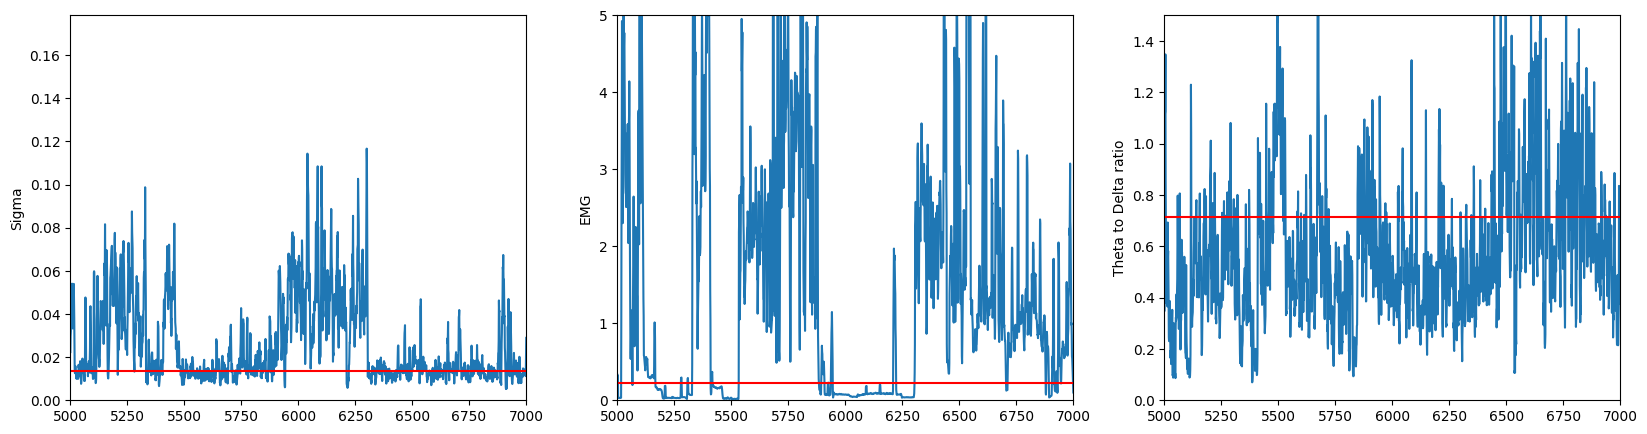

In [41]:
fig, axes = plt.subplots(1,3, figsize = (20,5))
axes = axes.flatten()

axes[0].plot(Spdl)
axes[0].hlines(y=Th, xmin=5000, xmax=7000, color = "red")
axes[0].set_ylabel('Sigma')
axes[0].set_ylim(0)
axes[0].set_xlim(5000,7000)

axes[1].plot(P_EMG_t)
axes[1].hlines(y=EMG_th, xmin=0, xmax=40000, color = "red")
axes[1].set_ylabel('EMG')
axes[1].set_ylim(0,5)
axes[1].set_xlim(5000,7000)

axes[2].plot(R)
axes[2].hlines(y=R_th, xmin=0, xmax=40000, color = "red")
axes[2].set_ylabel('Theta to Delta ratio')
axes[2].set_ylim(0,1.5)
axes[2].set_xlim(5000,7000)

In [42]:
# Calculate percentage of time spent in each state, or set to Nan if total time is 0
if total_time > 0:
    proportions = [np.sum(S==0)*T,np.sum(S==1)*T, np.sum(S==2)*T, np.sum(S==4)*T]
    proportions = np.array(proportions) / total_time * 100
else:
    proportions = [np.nan, np.nan, np.nan]

In [43]:
# Define 2-hour bins over 24 hours for Sleep Percentage Analysis
bin_edges = np.arange(0, 24*3600+1, 7200)
nbins_2hr = len(bin_edges) - 1

### Missing label of bins

### Sleep Percentage Analysis
bin_counts_Sleep = np.full(nbins_2hr, np.nan)
for b in range(nbins_2hr):
    idx = (tp >= bin_edges[b]) & (tp < bin_edges[b+1])
    if np.any(idx):
        S_bin = S[idx]
        bin_counts_Sleep[b] = (np.sum((S_bin==2) | (S_bin==4)) * T) / (bin_edges[b+1]-bin_edges[b]) * 100

### Wake Percentage Analysis
bin_counts_Wake = np.full(nbins_2hr, np.nan)
for b in range(nbins_2hr):
    idx = (tp >= bin_edges[b]) & (tp < bin_edges[b+1])
    if np.any(idx):
        S_bin = S[idx]
        bin_counts_Wake[b] = (np.sum((S_bin==1)) * T) / (bin_edges[b+1]-bin_edges[b]) * 100

### Wake Percentage Analysis
bin_counts_Unassigned = np.full(nbins_2hr, np.nan)
for b in range(nbins_2hr):
    idx = (tp >= bin_edges[b]) & (tp < bin_edges[b+1])
    if np.any(idx):
        S_bin = S[idx]
        bin_counts_Unassigned[b] = (np.sum((S_bin==0)) * T) / (bin_edges[b+1]-bin_edges[b]) * 100

In [44]:
### Bout Analysis
# S[S==4] = 3
# bin_epochs = int((6*3600)/T)
# nbins = len(S) // bin_epochs

# w, n, r, nd, rd = [np.full(nbins, np.nan) for _ in range(5)]
# for b in range(nbins):
#     segment = S[b*bin_epochs : (b+1)*bin_epochs]
#     w[b] = np.sum(np.diff(np.concatenate(([0], segment==1))) == 1)
#     n[b] = np.sum(np.diff(np.concatenate(([0], segment==2))) == 1)
#     r[b] = np.sum(np.diff(np.concatenate(([0], segment==3))) == 1)

#     def bout_durations(state):
#         durations, in_bout, bout_len = [], False, 0
#         for val in segment:
#             if val == state:
#                 bout_len += 1
#                 in_bout = True
#             elif in_bout:
#                 durations.append(bout_len * 5)
#                 bout_len, in_bout = 0, False
#         if in_bout:
#             durations.append(bout_len * 5)
#         return np.mean(durations) if durations else np.nan

#     nd[b] = bout_durations(2)
#     rd[b] = bout_durations(3)

In [45]:
### Summary file creation
summary = {
    'Unassigned': [proportions[0]],
    'WakePercent': [proportions[1]],
    'NREMPercent': [proportions[2]],
    'REMPercent': [proportions[3]]
}
for i, val in enumerate(bin_counts_Sleep):
    summary[f'SleepPercentage_{i}'] = [val]
for i, val in enumerate(bin_counts_Wake):
    summary[f'WakePercentage_{i}'] = [val]
# for i, val in enumerate(w):
#     summary[f'WakeBouts_{i}'] = [val]
# for i, val in enumerate(n):
#     summary[f'NREMBouts_{i}'] = [val]
# for i, val in enumerate(nd):
#     summary[f'NREMBoutDuration_{i}'] = [val]
# for i, val in enumerate(rd):
#     summary[f'REMBoutDuration_{i}'] = [val]
# for i, val in enumerate(r):
#     summary[f'REMBouts_{i}'] = [val]

summary_df = pd.DataFrame(summary)
summary_df.insert(0, 'FileName', file_name)
all_data = pd.concat([all_data, summary_df], ignore_index=True)

# all_data.to_excel(output_excel, index=False)

In [46]:
all_data

,FileName,Unassigned,WakePercent,NREMPercent,REMPercent,SleepPercentage_0,SleepPercentage_1,SleepPercentage_2,SleepPercentage_3,SleepPercentage_4,...,WakePercentage_2,WakePercentage_3,WakePercentage_4,WakePercentage_5,WakePercentage_6,WakePercentage_7,WakePercentage_8,WakePercentage_9,WakePercentage_10,WakePercentage_11
0,Exp2.2_3160.edf,14.089268,37.917863,35.075007,12.917863,42.805556,38.888889,49.722222,54.722222,57.527778,...,40.416667,33.75,33.638889,19.416667,27.027778,20.388889,50.638889,52.777778,51.111111,37.388889


(0.0, 150.0)

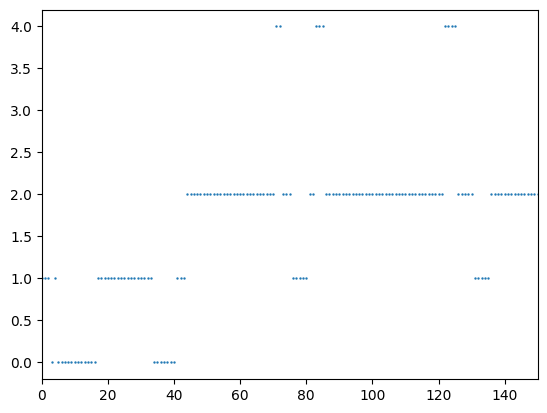

In [47]:
plt.scatter(x=range(len(S)),y=S, s = 0.5)
plt.xlim(0,150)
# plt.vlines(x = [0.5,4],ymin = 0, ymax= 0.01, linestyles='dashed', color = 'red')

In [48]:
Th

(0.013475094519595708+0j)

Text(0.5, 0, 'Time')

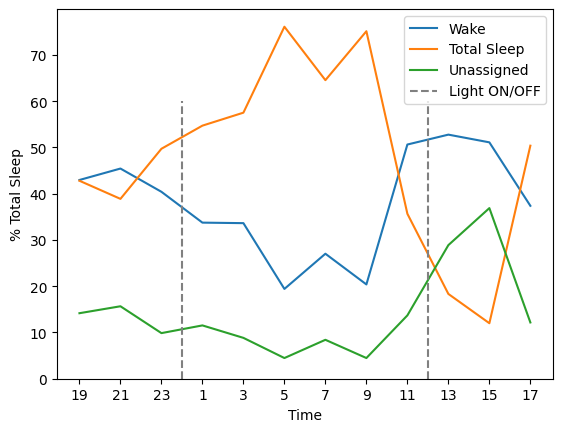

In [49]:
import matplotlib.pyplot as plt

plt.plot(bin_counts_Wake, label ='Wake')
plt.plot(bin_counts_Sleep, label = 'Total Sleep')
plt.plot(bin_counts_Unassigned, label = 'Unassigned')
plt.xticks(ticks = [0,1,2,3,4,5,6,7,8,9,10,11] ,labels = ['19',"21","23","1","3","5","7","9","11","13","15","17"])
plt.vlines(x=[2.5,8.5],ymin=0,ymax= 60, linestyles="dashed",color = "grey", label = 'Light ON/OFF')
plt.ylim(0)
plt.legend()
plt.ylabel('% Total Sleep')
plt.xlabel('Time')

In [50]:
bin_edges

array([    0,  7200, 14400, 21600, 28800, 36000, 43200, 50400, 57600,
       64800, 72000, 79200, 86400])

In [51]:
len(S)

43196